In [1]:
import numpy as np
import pandas as pd

In [5]:
df=pd.read_csv('Social_Network_Ads.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [9]:
df1=df.iloc[:,-3:]
df1

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [11]:
import seaborn as sns

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

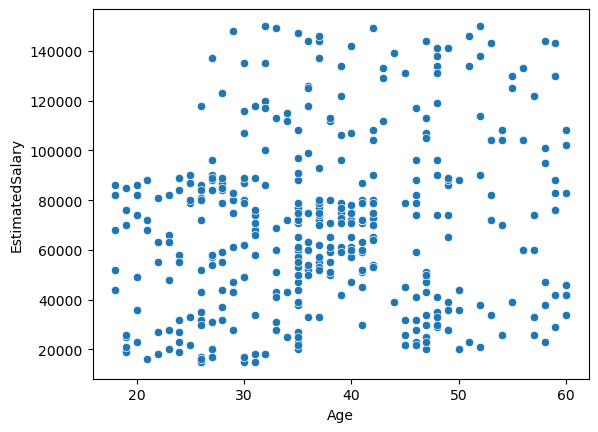

In [21]:
sns.scatterplot(x=df1.iloc[:,0],y=df1.iloc[:,1],data=df1)

In [31]:
x=df1.iloc[:,0:2]
y=df1.iloc[:,-1]

In [36]:
from sklearn.model_selection import train_test_split

In [38]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [40]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [44]:
model=Sequential()
model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))


C:\Users\cipl\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [50]:
history=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5372 - loss: 340.5862 - val_accuracy: 0.6000 - val_loss: 328.4505
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6102 - loss: 171.6972 - val_accuracy: 0.6000 - val_loss: 57.9163
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5251 - loss: 38.0057 - val_accuracy: 0.6000 - val_loss: 65.5316
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4625 - loss: 43.1710 - val_accuracy: 0.5000 - val_loss: 2.2301
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4633 - loss: 19.1349 - val_accuracy: 0.4000 - val_loss: 30.3685
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4940 - loss: 28.9701 - val_accuracy: 0.4000 - val_loss: 71.3567
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4255 - loss: 75.5457 - val_accuracy: 0.6000 - val_loss: 9.9434
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5511 - loss: 27.5539 - 

In [52]:
import matplotlib.pyplot as plt

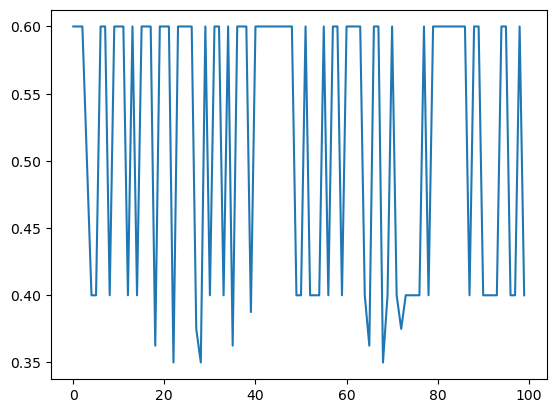

In [54]:
plt.plot(history.history['val_accuracy'])

# Apply feature Scaling

In [59]:
from sklearn.preprocessing import StandardScaler

In [61]:
st=StandardScaler()
x_train_scaled=st.fit_transform(x_train)
x_test_scaled=st.fit_transform(x_test)

In [65]:
x_test_scaled

array([[-0.74651519,  0.33929263],
       [-1.48154554, -1.59952242],
       [-0.01148485, -0.52883351],
       [-0.74651519,  0.10779233],
       [ 1.55045463, -0.03689536],
       [ 0.90730308, -1.48377227],
       [-1.29778795,  0.3103551 ],
       [-0.83839399, -1.13652181],
       [ 0.26415153, -0.32627074],
       [-0.10336364,  1.58360677],
       [-1.20590916, -1.39695965],
       [-1.38966674, -1.2812095 ],
       [-0.47087881,  1.32316893],
       [ 0.7235455 ,  0.22354248],
       [-0.19524244, -0.35520828],
       [-0.37900002, -0.81820889],
       [-1.66530312, -0.03689536],
       [ 2.10172739, -0.84714643],
       [ 1.45857584,  0.02097972],
       [-1.02215157, -0.81820889],
       [-0.01148485,  0.19460494],
       [ 0.7235455 , -0.76033381],
       [-0.6546364 , -0.26839567],
       [-0.10336364, -1.10758427],
       [-1.11403037,  0.25248002],
       [ 0.7235455 , -1.13652181],
       [ 0.7235455 , -1.42589719],
       [ 0.26415153, -0.41308336],
       [ 0.6316667 ,

In [67]:
model=Sequential()
model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))


C:\Users\cipl\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [71]:
history=model.fit(x_train_scaled,y_train,validation_data=(x_test_scaled,y_test),epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6533 - loss: 0.7099 - val_accuracy: 0.7000 - val_loss: 0.6655
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7782 - loss: 0.6383 - val_accuracy: 0.7375 - val_loss: 0.6043
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7704 - loss: 0.5885 - val_accuracy: 0.8000 - val_loss: 0.5516
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8690 - loss: 0.5382 - val_accuracy: 0.8000 - val_loss: 0.5082
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8349 - loss: 0.5035 - val_accuracy: 0.8000 - val_loss: 0.4727
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8505 - loss: 0.4786 - val_accuracy: 0.8000 - val_loss: 0.4405
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8643 - loss: 0.4418 - val_accuracy: 0.8125 - val_loss: 0.4148
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8610 - loss: 0.4316 - val_accuracy: 0.837

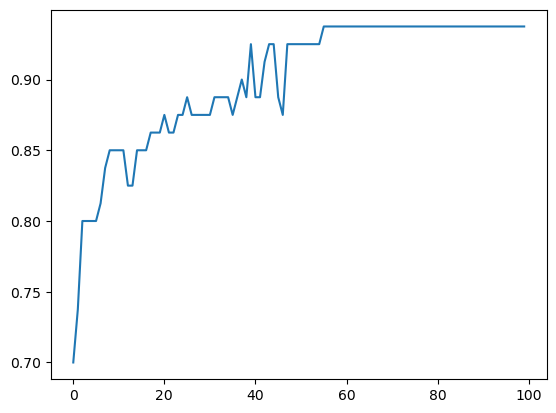

In [73]:
plt.plot(history.history['val_accuracy'])